In [ ]:
from pathlib import Path
import hashlib
import json
import re

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

print("Pustaka berhasil dimuat.")

Pustaka berhasil dimuat.


## 2. Mengunggah file CSV

Pilih file CSV kuesioner ketika tombol unggah muncul.

Apabila file CSV sudah berada di folder kerja Colab, notebook akan menggunakannya secara otomatis.

In [ ]:
csv_candidates = list(Path(".").glob("*.csv"))

if csv_candidates:
    CSV_PATH = csv_candidates[0]
    print("CSV ditemukan:", CSV_PATH)
else:
    try:
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("Tidak ada file yang diunggah.")
        CSV_PATH = Path(next(iter(uploaded.keys())))
        print("CSV diunggah:", CSV_PATH)
    except ImportError as exc:
        raise FileNotFoundError(
            "Letakkan file CSV di folder yang sama dengan notebook."
        ) from exc

Saving Kuesioner Tracer Study 2025 (Jawaban) (3).csv to Kuesioner Tracer Study 2025 (Jawaban) (3).csv
CSV diunggah: Kuesioner Tracer Study 2025 (Jawaban) (3).csv


## 3. Membaca CSV

Dataset menggunakan tanda titik koma (`;`) sebagai pemisah kolom dan format teks UTF-8.

In [ ]:
data_raw = pd.read_csv(
    CSV_PATH,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False,
)

print("Jumlah respons mentah :", len(data_raw))
print("Jumlah kolom          :", len(data_raw.columns))
data_raw.head(3)

Jumlah respons mentah : 1109
Jumlah kolom          : 76


,Timestamp,Email Address,Nama Lengkap,Tahun Lulus,Nomor Induk Mahasiswa (NIM),Kode Prodi,No Handphone / Whatsapp,No Tlpn. Orang Terdekat,Akun Facebook / instagram,NIK,...,"F.17(b) Pada saat ini, pada tingkat mana kompetensi di bawah ini diperlukan dalam pekerjaan?\n(5) Sangat Tinggi, (4) Tinggi, (3) Sedang, (2) Rendah, (1) Sangat Rendah) [Kerja sama tim]","F.17(b) Pada saat ini, pada tingkat mana kompetensi di bawah ini diperlukan dalam pekerjaan?\n(5) Sangat Tinggi, (4) Tinggi, (3) Sedang, (2) Rendah, (1) Sangat Rendah) [Pengembangan Diri]",Apakah Saudara berencana melanjutkan studi ke program Pascasarjana (S2) setelah menyelesaikan pendidikan saat ini?,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75
0,2/20/2023 13:46:49,nilotheresia@gmail.com,Theresia nilo,2015,NaN,SI : 57201,085250883219,081347497575,Nilo nyulir,6407096809890001,...,Sedang (3),Sedang (3),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11/28/2022 10:49:34,ridwan.syamsu@yahoo.co.id,Ridwan samau,2016,13.31.089,MI : 57401,085730578741,085347461115,Ridwan syam bahtiar,6472032610920007,...,Tinggi (4),Tinggi (4),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11/24/2022 12:39:50,sidiqazipurnomo@gmail.com,Sidiq Azi Purnomo,2017,17.41.019,SI : 57201,081380781979,081347908329,djss421,6472021612940001,...,Tinggi (4),Tinggi (4),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Menemukan kolom yang dibutuhkan

Nama kolom kuesioner cukup panjang. Fungsi berikut mencari kolom berdasarkan kata kunci sehingga kode lebih mudah dibaca.

In [ ]:
def normalisasi_header(teks):
    return re.sub(r"\s+", " ", str(teks).strip().lower())


def cari_kolom(kata_kunci, semua_kata_wajib=False):
    kata_kunci = [k.lower() for k in kata_kunci]

    for nama_kolom in data_raw.columns:
        nama_bersih = normalisasi_header(nama_kolom)

        if semua_kata_wajib:
            cocok = all(k in nama_bersih for k in kata_kunci)
        else:
            cocok = any(k in nama_bersih for k in kata_kunci)

        if cocok:
            return nama_kolom

    raise KeyError(f"Kolom tidak ditemukan untuk kata kunci: {kata_kunci}")


KOLOM = {
    "timestamp": cari_kolom(["timestamp"]),
    "email": cari_kolom(["email address"]),
    "nama": cari_kolom(["nama lengkap"]),
    "nim": cari_kolom(["nomor induk mahasiswa", "nim"]),
    "mencari_kerja": cari_kolom(["kapan anda mulai mencari", "f3."]),
    "jumlah_lamaran": cari_kolom(
        ["berapa perusahaan/instansi/institusi yang sudah anda lamar", "f6."]
    ),
    "status": cari_kolom(["jelaskan status anda saat ini", "f8."]),
    "comp_inggris": cari_kolom(["17(a)", "bahasa inggris"], semua_kata_wajib=True),
    "comp_it": cari_kolom(
        ["17(a)", "penggunaan teknologi informasi"], semua_kata_wajib=True
    ),
    "comp_komunikasi": cari_kolom(
        ["17(a)", "komunikasi"], semua_kata_wajib=True
    ),
    "comp_kerjasama": cari_kolom(
        ["17(a)", "kerja sama tim"], semua_kata_wajib=True
    ),
}

pd.DataFrame({
    "nama_sederhana": KOLOM.keys(),
    "kolom_csv": KOLOM.values(),
})

,nama_sederhana,kolom_csv
0,timestamp,Timestamp
1,email,Email Address
2,nama,Nama Lengkap
3,nim,Nomor Induk Mahasiswa (NIM)
4,mencari_kerja,f3. Kapan anda mulai mencari pekerjaan? (Mohon...
5,jumlah_lamaran,f6. Berapa perusahaan/instansi/institusi yang ...
6,status,f8. Jelaskan status Anda saat ini
7,comp_inggris,"F.17(a) Pada saat lulus, pada tingkat mana kom..."
8,comp_it,"F.17(a) Pada saat lulus, pada tingkat mana kom..."
9,comp_komunikasi,"F.17(a) Pada saat lulus, pada tingkat mana kom..."


## 5. Fungsi prapemrosesan

Aturan berikut disamakan dengan program impor Laravel:

- NIM dibersihkan dari spasi.
- NIM kosong diberi kode sementara berdasarkan nama dan email.
- Respons terakhir dari NIM yang sama digunakan.
- “Sebelum Lulus” menjadi `1`; pilihan lain menjadi `0`.
- Lamaran kosong atau “belum/tidak ada” menjadi `0`.
- “Banyak/tidak terhitung” menjadi `10`.
- Jumlah lamaran dibatasi maksimal `80`.
- Kompetensi kosong atau tidak dapat dibaca menjadi nilai tengah `3`.
- Bekerja, wirausaha, dan melanjutkan pendidikan menjadi kelas `1`.
- Belum bekerja atau mencari kerja menjadi kelas `0`.

In [ ]:
def teks_bersih(nilai):
    if pd.isna(nilai):
        return ""
    return str(nilai).strip()


def buat_nim_bersih(baris):
    nim = teks_bersih(baris[KOLOM["nim"]]).replace(" ", "")

    if nim:
        return nim

    # Sama seperti Laravel: NIM sementara dari nama dan email.
    identitas = (
        teks_bersih(baris[KOLOM["nama"]])
        + teks_bersih(baris[KOLOM["email"]])
    )
    kode = hashlib.md5(identitas.encode("utf-8")).hexdigest()[:8]
    return "TEMP-" + kode


def ubah_mencari_sebelum_lulus(nilai):
    teks = teks_bersih(nilai).lower()
    return 1 if "sebelum" in teks else 0


def ubah_jumlah_lamaran(nilai):
    teks = teks_bersih(nilai).lower()

    if (
        not teks
        or "tidak ada" in teks
        or "belum" in teks
    ):
        return 0

    if "banyak" in teks or "tidak terhitung" in teks:
        return 10

    angka = re.search(r"\d+", teks)
    if angka:
        return min(int(angka.group()), 80)

    return 0


def ubah_skor_kompetensi(nilai):
    teks = teks_bersih(nilai)

    if not teks:
        return 3.0

    try:
        skor = float(teks)
    except ValueError:
        angka_dalam_kurung = re.search(r"\((\d+)\)", teks)
        skor = float(angka_dalam_kurung.group(1)) if angka_dalam_kurung else 3.0

    # Menjaga skor tetap pada skala kuesioner 1 sampai 5.
    if not 1 <= skor <= 5:
        return 3.0

    return skor


def ubah_status(nilai):
    teks = teks_bersih(nilai).lower()

    # Pemeriksaan status belum bekerja dilakukan lebih dahulu.
    if any(kata in teks for kata in [
        "tidak kerja",
        "tidak bekerja",
        "menganggur",
        "belum",
        "mencari kerja",
    ]):
        return "Belum Bekerja / Mencari Kerja"

    if any(kata in teks for kata in [
        "wiraswasta",
        "wirausaha",
        "bisnis sendiri",
    ]):
        return "Wirausaha"

    if any(kata in teks for kata in [
        "kuliah",
        "melanjutkan",
        "studi",
    ]):
        return "Melanjutkan Pendidikan"

    if "bekerja" in teks:
        return "Bekerja"

    # Status kosong dianggap belum terserap, sama seperti nilai awal pada Laravel.
    return "Belum Bekerja / Mencari Kerja"


def ubah_target(status):
    status_terserap = {
        "Bekerja",
        "Wirausaha",
        "Melanjutkan Pendidikan",
    }
    return 1 if status in status_terserap else 0


print("Fungsi prapemrosesan siap digunakan.")

Fungsi prapemrosesan siap digunakan.


## 6. Membentuk dataset pemodelan

Dataset hanya menyimpan NIM sementara untuk proses menghapus respons ganda. NIM tidak dimasukkan sebagai fitur model.

In [ ]:
data_kerja = data_raw.copy()

# Baris tanpa nama tidak diimpor oleh web.
data_kerja = data_kerja[
    data_kerja[KOLOM["nama"]].fillna("").astype(str).str.strip().ne("")
].copy()

data_kerja["nim_bersih"] = data_kerja.apply(buat_nim_bersih, axis=1)

# CSV tersusun menurut waktu pengisian. Respons terakhir dipertahankan.
jumlah_sebelum_deduplikasi = len(data_kerja)
data_kerja = data_kerja.drop_duplicates(
    subset="nim_bersih",
    keep="last",
).copy()
jumlah_duplikat_dihapus = jumlah_sebelum_deduplikasi - len(data_kerja)

dataset = pd.DataFrame({
    "mencari_sebelum_lulus": data_kerja[KOLOM["mencari_kerja"]]
        .map(ubah_mencari_sebelum_lulus),
    "jumlah_lamaran": data_kerja[KOLOM["jumlah_lamaran"]]
        .map(ubah_jumlah_lamaran),
    "comp_it": data_kerja[KOLOM["comp_it"]]
        .map(ubah_skor_kompetensi),
    "comp_inggris": data_kerja[KOLOM["comp_inggris"]]
        .map(ubah_skor_kompetensi),
    "comp_komunikasi": data_kerja[KOLOM["comp_komunikasi"]]
        .map(ubah_skor_kompetensi),
    "comp_kerjasama": data_kerja[KOLOM["comp_kerjasama"]]
        .map(ubah_skor_kompetensi),
    "status": data_kerja[KOLOM["status"]].map(ubah_status),
})

dataset["target"] = dataset["status"].map(ubah_target)
dataset = dataset.reset_index(drop=True)

print("Respons sebelum deduplikasi :", jumlah_sebelum_deduplikasi)
print("Respons ganda yang dihapus  :", jumlah_duplikat_dihapus)
print("Alumni unik untuk pemodelan :", len(dataset))

dataset.head(10)

Respons sebelum deduplikasi : 999
Respons ganda yang dihapus  : 195
Alumni unik untuk pemodelan : 804


,mencari_sebelum_lulus,jumlah_lamaran,comp_it,comp_inggris,comp_komunikasi,comp_kerjasama,status,target
0,0,2,4.0,3.0,4.0,4.0,Belum Bekerja / Mencari Kerja,0
1,1,4,4.0,3.0,4.0,4.0,Bekerja,1
2,0,1,4.0,4.0,4.0,4.0,Belum Bekerja / Mencari Kerja,0
3,0,1,5.0,5.0,5.0,5.0,Bekerja,1
4,0,1,4.0,3.0,3.0,3.0,Belum Bekerja / Mencari Kerja,0
5,0,6,4.0,4.0,4.0,5.0,Bekerja,1
6,0,4,5.0,4.0,5.0,5.0,Bekerja,1
7,1,4,5.0,4.0,5.0,4.0,Bekerja,1
8,1,2,4.0,5.0,4.0,5.0,Bekerja,1
9,1,3,4.0,3.0,4.0,4.0,Bekerja,1


## 7. Memeriksa hasil prapemrosesan

Pemeriksaan ini memastikan seluruh variabel memiliki rentang nilai yang sesuai dengan input web.

In [ ]:
FEATURES = [
    "mencari_sebelum_lulus",
    "jumlah_lamaran",
    "comp_it",
    "comp_inggris",
    "comp_komunikasi",
    "comp_kerjasama",
]

assert dataset["mencari_sebelum_lulus"].isin([0, 1]).all()
assert dataset["jumlah_lamaran"].between(0, 80).all()
assert dataset[
    ["comp_it", "comp_inggris", "comp_komunikasi", "comp_kerjasama"]
].apply(lambda kolom: kolom.between(1, 5)).all(axis=None)
assert dataset["target"].isin([0, 1]).all()
assert not dataset[FEATURES + ["target"]].isna().any().any()

ringkasan_fitur = dataset[FEATURES + ["target"]].describe().T
ringkasan_fitur

,count,mean,std,min,25%,50%,75%,max
mencari_sebelum_lulus,804.0,0.299751,0.458434,0.0,0.0,0.0,1.0,1.0
jumlah_lamaran,804.0,2.741294,5.398006,0.0,1.0,2.0,3.0,80.0
comp_it,804.0,3.997512,0.731769,2.0,3.0,4.0,5.0,5.0
comp_inggris,804.0,3.427861,0.799140,1.0,3.0,3.0,4.0,5.0
comp_komunikasi,804.0,4.060945,0.771547,1.0,4.0,4.0,5.0,5.0
comp_kerjasama,804.0,4.217662,0.727428,1.0,4.0,4.0,5.0,5.0
target,804.0,0.508706,0.500235,0.0,0.0,1.0,1.0,1.0


## 8. Melihat distribusi target

- `0` berarti **Tidak Terserap**.
- `1` berarti **Terserap**.

In [ ]:
distribusi_target = (
    dataset["target"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Tidak Terserap", 1: "Terserap"})
)

distribusi_target

,count
target,
Tidak Terserap,395
Terserap,409


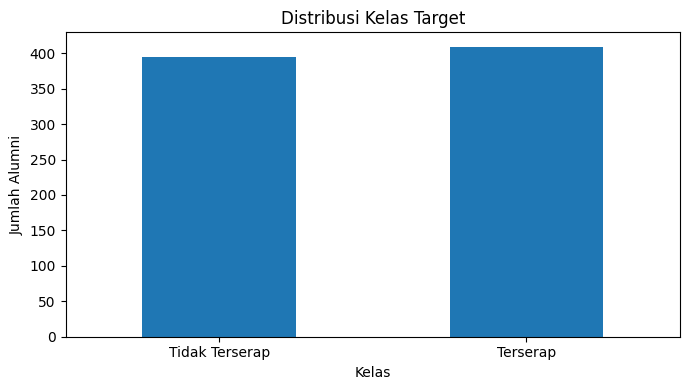

In [ ]:
plt.figure(figsize=(7, 4))
distribusi_target.plot(kind="bar")
plt.title("Distribusi Kelas Target")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Alumni")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Membagi data latih dan data uji

Sebanyak 80% data dipakai untuk pelatihan dan 20% untuk pengujian.

Parameter `stratify=y` menjaga proporsi kelas pada data latih dan data uji.

In [ ]:
X = dataset[FEATURES].astype(float)
y = dataset["target"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Data latih :", len(X_train))
print("Data uji   :", len(X_test))
print()
print("Proporsi target data latih:")
print(y_train.value_counts(normalize=True).sort_index())
print()
print("Proporsi target data uji:")
print(y_test.value_counts(normalize=True).sort_index())

Data latih : 643
Data uji   : 161

Proporsi target data latih:
target
0    0.491446
1    0.508554
Name: proportion, dtype: float64

Proporsi target data uji:
target
0    0.490683
1    0.509317
Name: proportion, dtype: float64


## 10. Mencari parameter Random Forest

`GridSearchCV` mencoba beberapa kombinasi parameter. Parameter dipilih berdasarkan rata-rata *balanced accuracy* pada lima lipatan data latih.

In [ ]:
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

parameter_random_forest = {
    "n_estimators": [200],
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [5, 10, 20],
    "max_features": ["sqrt"],
    "class_weight": ["balanced"],
}

pencarian_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_grid=parameter_random_forest,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

pencarian_rf.fit(X_train, y_train)
model_rf_terbaik = pencarian_rf.best_estimator_

print("Parameter Random Forest terbaik:")
pencarian_rf.best_params_

Parameter Random Forest terbaik:


{'class_weight': 'balanced',
 'max_depth': 3,
 'max_features': 'sqrt',
 'min_samples_leaf': 5,
 'n_estimators': 200}

## 11. Membandingkan tiga algoritma

Perbandingan tidak menggunakan data uji. Semua model dinilai melalui *5-fold cross-validation* pada data latih.

In [ ]:
model_pembanding = {
    "Logistic Regression": Pipeline([
        ("standardisasi", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=7,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": model_rf_terbaik,
}

metrik_cv = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

hasil_perbandingan = []

for nama_model, model in model_pembanding.items():
    skor = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=metrik_cv,
        return_train_score=True,
        n_jobs=-1,
    )

    hasil_perbandingan.append({
        "Model": nama_model,
        "Accuracy (%)": skor["test_accuracy"].mean() * 100,
        "Balanced Accuracy (%)": skor["test_balanced_accuracy"].mean() * 100,
        "Precision (%)": skor["test_precision"].mean() * 100,
        "Recall (%)": skor["test_recall"].mean() * 100,
        "F1-score (%)": skor["test_f1"].mean() * 100,
        "Std. Balanced Accuracy": skor["test_balanced_accuracy"].std() * 100,
        "Train Accuracy (%)": skor["train_accuracy"].mean() * 100,
    })

tabel_perbandingan = pd.DataFrame(hasil_perbandingan).round(2)
tabel_perbandingan

,Model,Accuracy (%),Balanced Accuracy (%),Precision (%),Recall (%),F1-score (%),Std. Balanced Accuracy,Train Accuracy (%)
0,Logistic Regression,70.46,70.83,86.40,49.56,62.93,4.04,70.65
1,Decision Tree,68.43,68.69,77.00,54.14,63.36,3.95,72.51
2,Random Forest,71.71,72.00,83.43,55.08,66.26,4.25,71.93


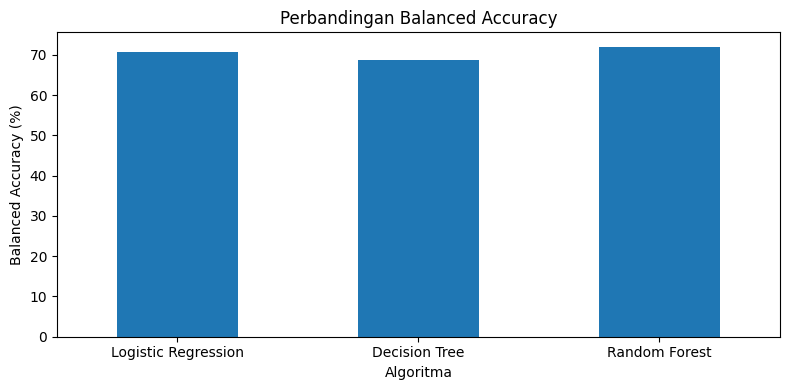

In [ ]:
plt.figure(figsize=(8, 4))
tabel_perbandingan.set_index("Model")["Balanced Accuracy (%)"].plot(kind="bar")
plt.title("Perbandingan Balanced Accuracy")
plt.xlabel("Algoritma")
plt.ylabel("Balanced Accuracy (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. Membandingkan penggunaan `class_weight`

Bagian ini memperlihatkan pengaruh penyeimbangan bobot kelas pada Random Forest.

In [ ]:
model_tanpa_bobot = clone(model_rf_terbaik).set_params(class_weight=None)
model_dengan_bobot = clone(model_rf_terbaik).set_params(class_weight="balanced")

hasil_bobot = []

for nama, model in {
    "Tanpa class_weight": model_tanpa_bobot,
    "class_weight=balanced": model_dengan_bobot,
}.items():
    skor = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=metrik_cv,
        n_jobs=-1,
    )

    hasil_bobot.append({
        "Pengaturan": nama,
        "Accuracy (%)": skor["test_accuracy"].mean() * 100,
        "Balanced Accuracy (%)": skor["test_balanced_accuracy"].mean() * 100,
        "Precision (%)": skor["test_precision"].mean() * 100,
        "Recall (%)": skor["test_recall"].mean() * 100,
        "F1-score (%)": skor["test_f1"].mean() * 100,
    })

tabel_class_weight = pd.DataFrame(hasil_bobot).round(2)
tabel_class_weight

,Pengaturan,Accuracy (%),Balanced Accuracy (%),Precision (%),Recall (%),F1-score (%)
0,Tanpa class_weight,71.39,71.68,82.68,55.08,66.01
1,class_weight=balanced,71.71,72.00,83.43,55.08,66.26


## 13. Menguji Random Forest pada data uji

Data uji belum pernah digunakan untuk mencari parameter atau melatih model. Karena itu, hasil ini dipakai sebagai evaluasi independen.

In [ ]:
model_evaluasi = clone(model_rf_terbaik)
model_evaluasi.fit(X_train, y_train)

prediksi_train = model_evaluasi.predict(X_train)
prediksi_test = model_evaluasi.predict(X_test)

akurasi_train = accuracy_score(y_train, prediksi_train)
akurasi_test = accuracy_score(y_test, prediksi_test)
balanced_accuracy = balanced_accuracy_score(y_test, prediksi_test)
precision = precision_score(y_test, prediksi_test, zero_division=0)
recall = recall_score(y_test, prediksi_test, zero_division=0)
f1 = f1_score(y_test, prediksi_test, zero_division=0)
gap = akurasi_train - akurasi_test

hasil_holdout = pd.DataFrame({
    "Metrik": [
        "Akurasi data latih",
        "Akurasi data uji",
        "Balanced accuracy data uji",
        "Precision kelas Terserap",
        "Recall kelas Terserap",
        "F1-score kelas Terserap",
        "Selisih akurasi latih-uji",
    ],
    "Nilai (%)": [
        akurasi_train * 100,
        akurasi_test * 100,
        balanced_accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100,
        gap * 100,
    ],
}).round(2)

hasil_holdout

,Metrik,Nilai (%)
0,Akurasi data latih,71.85
1,Akurasi data uji,72.67
2,Balanced accuracy data uji,72.87
3,Precision kelas Terserap,79.69
4,Recall kelas Terserap,62.20
5,F1-score kelas Terserap,69.86
6,Selisih akurasi latih-uji,-0.82


In [ ]:
# Menghitung metrik untuk kelas Tidak Terserap (label 0)
precision_tidak_terserap = precision_score(
    y_test,
    prediksi_test,
    pos_label=0,
    zero_division=0
)

recall_tidak_terserap = recall_score(
    y_test,
    prediksi_test,
    pos_label=0,
    zero_division=0
)

f1_tidak_terserap = f1_score(
    y_test,
    prediksi_test,
    pos_label=0,
    zero_division=0
)

# Menampilkan hasil dalam bentuk tabel
metrik_tidak_terserap = pd.DataFrame({
    "Metrik": [
        "Precision kelas Tidak Terserap",
        "Recall kelas Tidak Terserap",
        "F1-score kelas Tidak Terserap",
    ],
    "Nilai (%)": [
        precision_tidak_terserap * 100,
        recall_tidak_terserap * 100,
        f1_tidak_terserap * 100,
    ],
}).round(2)

metrik_tidak_terserap

,Metrik,Nilai (%)
0,Precision kelas Tidak Terserap,68.04
1,Recall kelas Tidak Terserap,83.54
2,F1-score kelas Tidak Terserap,75.00


## 14. Matriks kebingungan dan metrik per kelas

Susunan matriks:

- Baris = kelas aktual.
- Kolom = kelas prediksi.
- Kelas `0` = Tidak Terserap.
- Kelas `1` = Terserap.

True Negative  (TN): 66
False Positive (FP): 13
False Negative (FN): 31
True Positive  (TP): 51


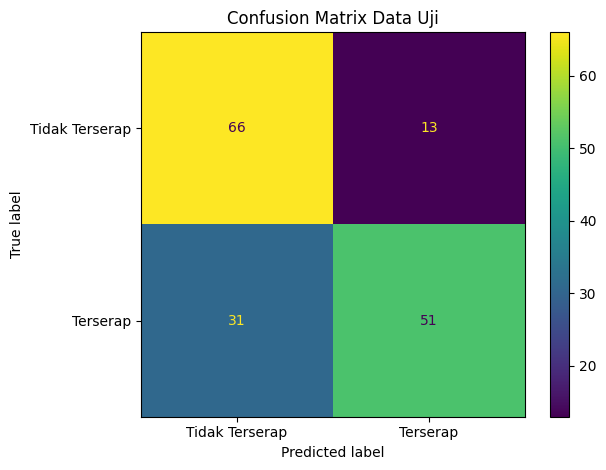

In [ ]:
matriks = confusion_matrix(
    y_test,
    prediksi_test,
    labels=[0, 1],
)

tn, fp, fn, tp = matriks.ravel()

print("True Negative  (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive  (TP):", tp)

display = ConfusionMatrixDisplay(
    confusion_matrix=matriks,
    display_labels=["Tidak Terserap", "Terserap"],
)
display.plot()
plt.title("Confusion Matrix Data Uji")
plt.tight_layout()
plt.show()

In [ ]:
laporan_per_kelas = pd.DataFrame(
    classification_report(
        y_test,
        prediksi_test,
        target_names=["Tidak Terserap", "Terserap"],
        output_dict=True,
        zero_division=0,
    )
).T

laporan_per_kelas

,precision,recall,f1-score,support
Tidak Terserap,0.680412,0.835443,0.750000,79.000000
Terserap,0.796875,0.621951,0.698630,82.000000
accuracy,0.726708,0.726708,0.726708,0.726708
macro avg,0.738644,0.728697,0.724315,161.000000
weighted avg,0.739729,0.726708,0.723836,161.000000


### Cara membaca FP dan FN

Dengan kelas positif `1 = Terserap`:

- **False Positive (FP)**: alumni sebenarnya tidak terserap, tetapi diprediksi terserap. Risiko praktisnya adalah institusi dapat melewatkan alumni yang sebenarnya membutuhkan bantuan karier.
- **False Negative (FN)**: alumni sebenarnya terserap, tetapi diprediksi tidak terserap. Risiko praktisnya adalah institusi dapat memberikan intervensi kepada alumni yang sebenarnya tidak memerlukannya.

Dalam penggunaan institusional, perhatian utama umumnya diberikan pada FP karena alumni yang belum terserap dapat tidak teridentifikasi.

## 15. Melihat tingkat kepentingan fitur

Nilai lebih tinggi berarti fitur lebih sering membantu Random Forest dalam membuat keputusan.

In [ ]:
kepentingan_fitur = (
    pd.DataFrame({
        "Fitur": FEATURES,
        "Kepentingan (%)": model_evaluasi.feature_importances_ * 100,
    })
    .sort_values("Kepentingan (%)", ascending=False)
    .reset_index(drop=True)
)

kepentingan_fitur.round(2)

,Fitur,Kepentingan (%)
0,mencari_sebelum_lulus,71.97
1,comp_inggris,9.38
2,jumlah_lamaran,6.32
3,comp_it,4.79
4,comp_komunikasi,4.25
5,comp_kerjasama,3.29


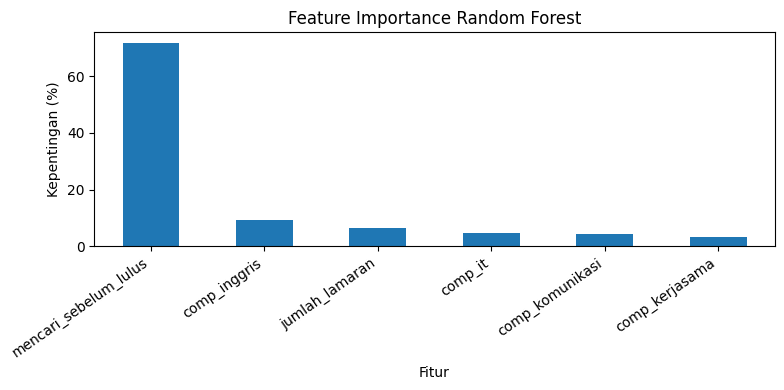

In [ ]:
plt.figure(figsize=(8, 4))
kepentingan_fitur.set_index("Fitur")["Kepentingan (%)"].plot(kind="bar")
plt.title("Feature Importance Random Forest")
plt.xlabel("Fitur")
plt.ylabel("Kepentingan (%)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 16. Melatih model untuk dipasang ke web

Evaluasi telah selesai menggunakan data uji. Setelah itu, model operasional dilatih kembali menggunakan seluruh 804 alumni.

File `random_forest_model.joblib` dapat menggantikan file model di folder `ml-api` web Anda.

In [ ]:
model_deployment = clone(model_rf_terbaik)
model_deployment.fit(X, y)

MODEL_PATH = Path("random_forest_model.joblib")
joblib.dump(model_deployment, MODEL_PATH)

print("Model tersimpan:", MODEL_PATH.resolve())

Model tersimpan: /content/random_forest_model.joblib


## 17. Menyimpan hasil penelitian

Dataset bersih tidak memuat nama, email, NIK, NPWP, atau nomor telepon.

In [ ]:
DATASET_BERSIH_PATH = Path("dataset_modeling_bersih.csv")
PERBANDINGAN_PATH = Path("model_comparison_csv.csv")
BOBOT_PATH = Path("class_weight_comparison_csv.csv")
EVALUASI_PATH = Path("holdout_evaluation_csv.csv")
FITUR_PATH = Path("feature_importance_csv.csv")
METADATA_PATH = Path("model_metadata_csv.json")

dataset.to_csv(DATASET_BERSIH_PATH, index=False)
tabel_perbandingan.to_csv(PERBANDINGAN_PATH, index=False)
tabel_class_weight.to_csv(BOBOT_PATH, index=False)
hasil_holdout.to_csv(EVALUASI_PATH, index=False)
kepentingan_fitur.to_csv(FITUR_PATH, index=False)

metadata = {
    "sumber_data": str(CSV_PATH),
    "respons_mentah": int(len(data_raw)),
    "alumni_unik": int(len(dataset)),
    "duplikat_dihapus": int(jumlah_duplikat_dihapus),
    "distribusi_target": {
        "tidak_terserap": int((y == 0).sum()),
        "terserap": int((y == 1).sum()),
    },
    "protokol_evaluasi": (
        "Stratified hold-out 80:20 dan 5-fold stratified cross-validation "
        "pada data latih"
    ),
    "parameter_random_forest": pencarian_rf.best_params_,
    "hasil_data_uji_persen": {
        "train_accuracy": round(akurasi_train * 100, 2),
        "test_accuracy": round(akurasi_test * 100, 2),
        "balanced_accuracy": round(balanced_accuracy * 100, 2),
        "precision_terserap": round(precision * 100, 2),
        "recall_terserap": round(recall * 100, 2),
        "f1_terserap": round(f1 * 100, 2),
        "train_test_gap": round(gap * 100, 2),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    },
}

with METADATA_PATH.open("w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=4, ensure_ascii=False)

print("Berkas hasil:")
for lokasi in [
    MODEL_PATH,
    DATASET_BERSIH_PATH,
    PERBANDINGAN_PATH,
    BOBOT_PATH,
    EVALUASI_PATH,
    FITUR_PATH,
    METADATA_PATH,
]:
    print("-", lokasi)

Berkas hasil:
- random_forest_model.joblib
- dataset_modeling_bersih.csv
- model_comparison_csv.csv
- class_weight_comparison_csv.csv
- holdout_evaluation_csv.csv
- feature_importance_csv.csv
- model_metadata_csv.json


## 18. Contoh prediksi satu alumni

Urutan enam input harus sama dengan fitur di web.

In [ ]:
def prediksi_satu_alumni(
    mencari_sebelum_lulus,
    jumlah_lamaran,
    comp_it,
    comp_inggris,
    comp_komunikasi,
    comp_kerjasama,
):
    nilai = [
        mencari_sebelum_lulus,
        jumlah_lamaran,
        comp_it,
        comp_inggris,
        comp_komunikasi,
        comp_kerjasama,
    ]

    if mencari_sebelum_lulus not in [0, 1]:
        raise ValueError("mencari_sebelum_lulus harus 0 atau 1.")

    if not 0 <= jumlah_lamaran <= 80:
        raise ValueError("jumlah_lamaran harus berada pada rentang 0-80.")

    if any(not 1 <= skor <= 5 for skor in nilai[2:]):
        raise ValueError("Skor kompetensi harus berada pada rentang 1-5.")

    input_baru = pd.DataFrame(
        [nilai],
        columns=FEATURES,
    )

    kode = int(model_deployment.predict(input_baru)[0])
    probabilitas = model_deployment.predict_proba(input_baru)[0]
    indeks_kelas = list(model_deployment.classes_).index(kode)
    keyakinan = float(probabilitas[indeks_kelas])

    return {
        "kode": kode,
        "hasil": "Terserap" if kode == 1 else "Tidak Terserap",
        "keyakinan_persen": round(keyakinan * 100, 2),
    }


contoh_hasil = prediksi_satu_alumni(
    mencari_sebelum_lulus=1,
    jumlah_lamaran=5,
    comp_it=4,
    comp_inggris=3,
    comp_komunikasi=4,
    comp_kerjasama=5,
)

contoh_hasil

{'kode': 1, 'hasil': 'Terserap', 'keyakinan_persen': 73.65}

## 19. Mengunduh model dan hasil

Jalankan sel berikut di Google Colab untuk mengunduh semua berkas hasil sebagai ZIP.

In [ ]:
import zipfile

PAKET_PATH = Path("hasil_model_csv.zip")

with zipfile.ZipFile(PAKET_PATH, "w", zipfile.ZIP_DEFLATED) as paket:
    for lokasi in [
        MODEL_PATH,
        DATASET_BERSIH_PATH,
        PERBANDINGAN_PATH,
        BOBOT_PATH,
        EVALUASI_PATH,
        FITUR_PATH,
        METADATA_PATH,
    ]:
        paket.write(lokasi, arcname=lokasi.name)

print("Paket siap:", PAKET_PATH.resolve())

try:
    from google.colab import files
    files.download(str(PAKET_PATH))
except ImportError:
    print("Notebook tidak berjalan di Colab. Ambil file ZIP dari folder kerja.")

Paket siap: /content/hasil_model_csv.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>